In [34]:
import os

os.makedirs("datasets", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [35]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib


In [36]:
df = pd.read_csv("/content/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [37]:
print("Rows and Columns:", df.shape)

print()

df.info()


Rows and Columns: (768, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [38]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [39]:
(df == 0).sum()

,0
Pregnancies,111
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [40]:
print("Dataset Shape:")
print(df.shape)

print("\nOutcome Distribution:")
print(df["Outcome"].value_counts())

print("\nData Types:")
print(df.dtypes)

print("\nMinimum Values:")
print(df.min())

print("\nMaximum Values:")
print(df.max())

Dataset Shape:
(768, 9)

Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Minimum Values:
Pregnancies                  0.000
Glucose                     44.000
BloodPressure               24.000
SkinThickness                7.000
Insulin                     14.000
BMI                         18.200
DiabetesPedigreeFunction     0.078
Age                         21.000
Outcome                      0.000
dtype: float64

Maximum Values:
Pregnancies                  17.00
Glucose                     199.00
BloodPressure               122.00
SkinThickness                99.00
Insulin                     846.00
BMI        

In [41]:
print("Duplicate rows:", df.duplicated().sum())

print("\nZero values in each column:")
print((df == 0).sum())

print("\nMedian values:")
print(df.median())

Duplicate rows: 0

Zero values in each column:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Median values:
Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                28.0000
Insulin                     102.5000
BMI                          32.0500
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64


In [42]:
!pip install -q openml # previous dataset was preprocessed which might have caused us problem


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 47.7 MB/s eta 0:00:00


In [43]:
!pip install -q openml

In [44]:
import openml

dataset = openml.datasets.get_dataset(
    37,
    download_data=True
)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute
)

df_raw = X.copy()
df_raw["Outcome"] = y

print("Shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

display(df_raw.head())

Shape: (768, 9)

Columns:
['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'Outcome']


,preg,plas,pres,skin,insu,mass,pedi,age,Outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,tested_positive
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,tested_negative
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,tested_positive
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,tested_negative
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,tested_positive


In [45]:
df_raw = df_raw.rename(columns={
    "preg": "Pregnancies",
    "plas": "Glucose",
    "pres": "BloodPressure",
    "skin": "SkinThickness",
    "insu": "Insulin",
    "mass": "BMI",
    "pedi": "DiabetesPedigreeFunction",
    "age": "Age"
})

print(df_raw.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [46]:
df_raw["Outcome"] = df_raw["Outcome"].map({
    "tested_negative": 0,
    "tested_positive": 1
})

print(df_raw["Outcome"].value_counts())


Outcome
0    500
1    268
Name: count, dtype: int64


In [47]:
print("Missing values in each column:")
print(df_raw.isnull().sum())

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [48]:
print("Zero values in each column:")
print((df_raw == 0).sum())

Zero values in each column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [49]:
print("Number of duplicate rows:", df_raw.duplicated().sum())

Number of duplicate rows: 0


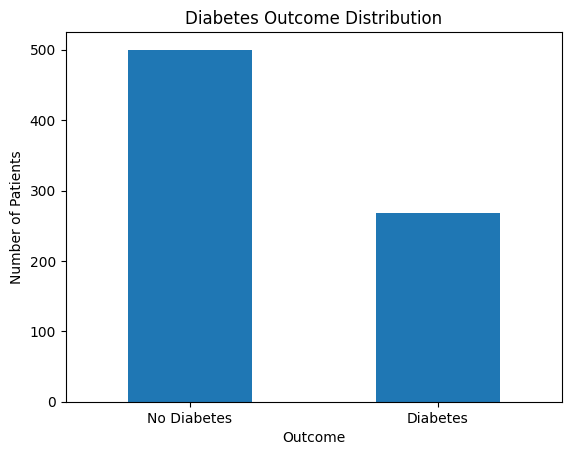

In [50]:
import matplotlib.pyplot as plt

df_raw["Outcome"].value_counts().plot(kind="bar")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"], rotation=0)
plt.show()

In [51]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [52]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [53]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [54]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [55]:
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


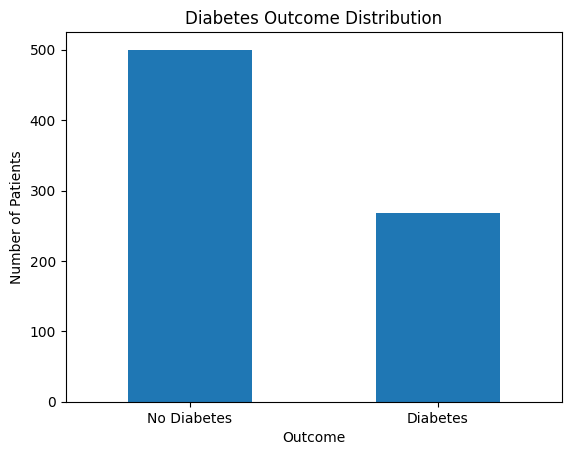

In [56]:
import matplotlib.pyplot as plt

df['Outcome'].value_counts().plot(kind='bar')

plt.xlabel('Outcome')
plt.ylabel('Number of Patients')
plt.title('Diabetes Outcome Distribution')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'], rotation=0)

plt.show()

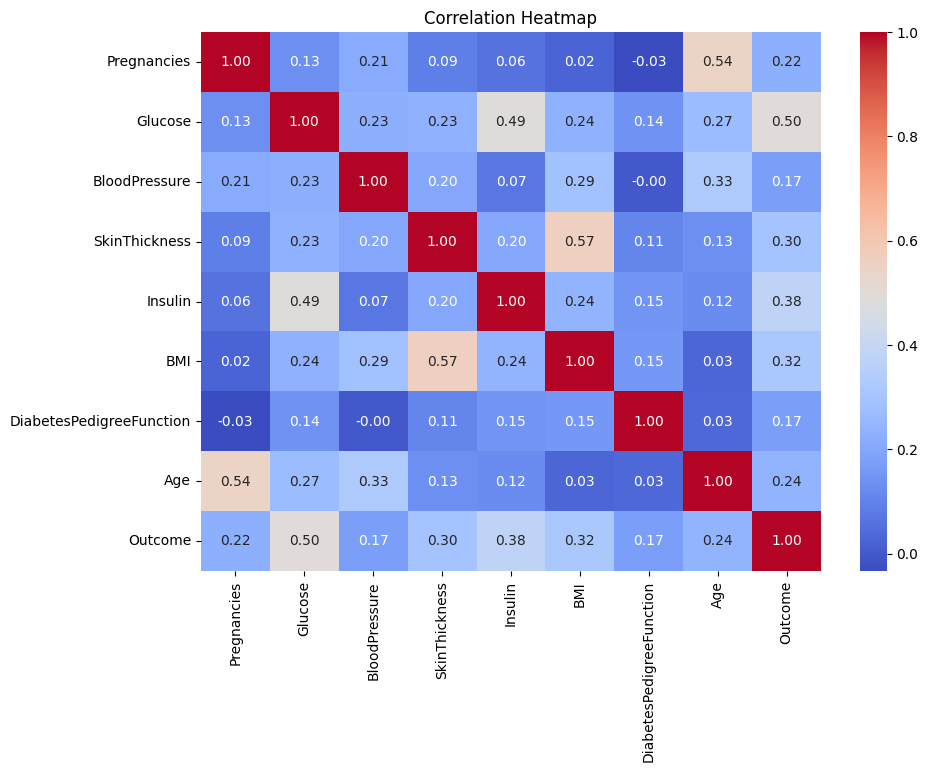

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [58]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


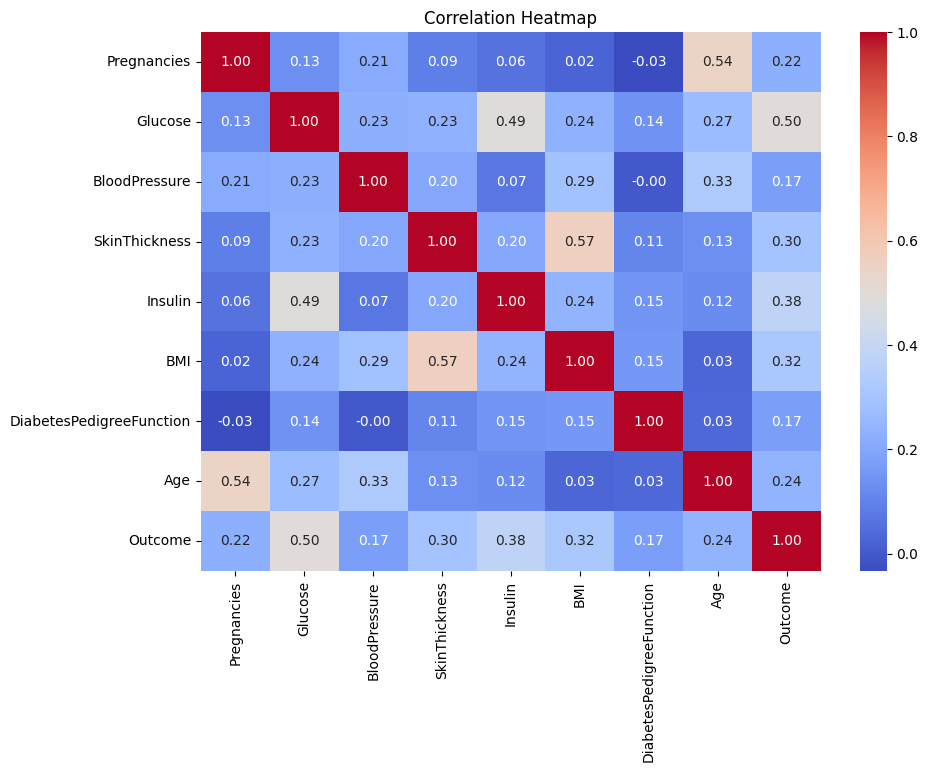

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

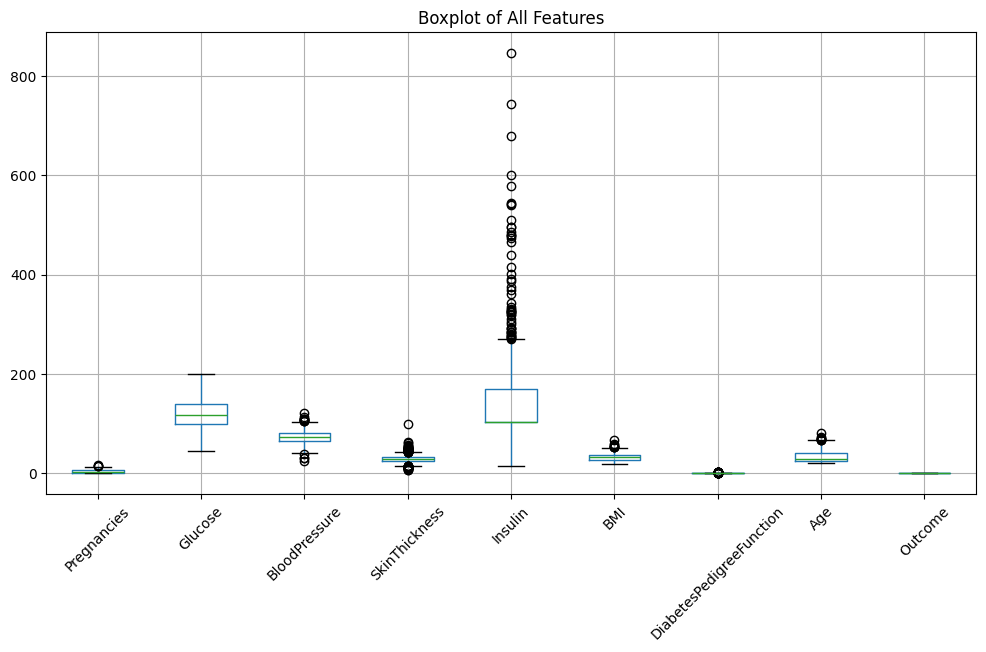

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

df.boxplot()

plt.title('Boxplot of All Features')
plt.xticks(rotation=45)
plt.show()

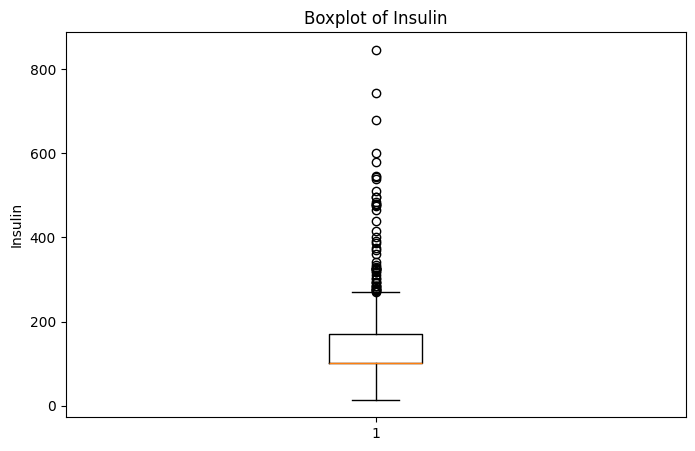

In [61]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['Insulin'])

plt.title('Boxplot of Insulin')
plt.ylabel('Insulin')

plt.show()

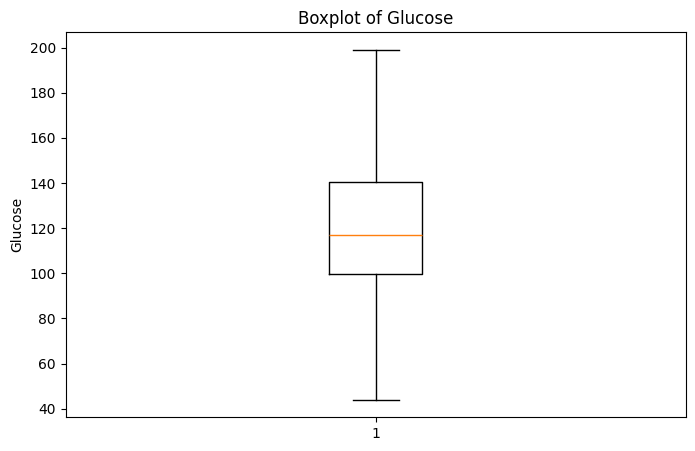

In [62]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['Glucose'])

plt.title('Boxplot of Glucose')
plt.ylabel('Glucose')

plt.show()

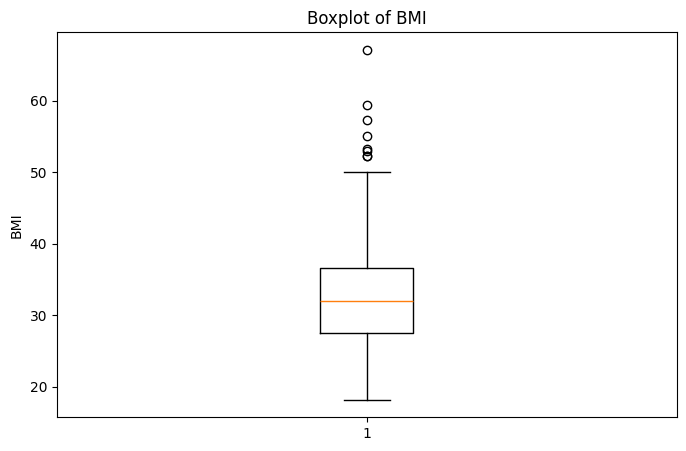

In [63]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['BMI'])

plt.title('Boxplot of BMI')
plt.ylabel('BMI')

plt.show()

In [64]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

(df[cols] == 0).sum()

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


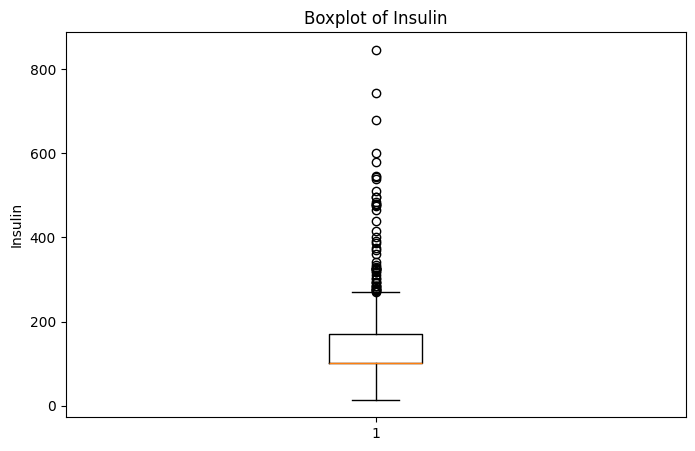

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(df['Insulin'])

plt.title('Boxplot of Insulin')
plt.ylabel('Insulin')

plt.show()

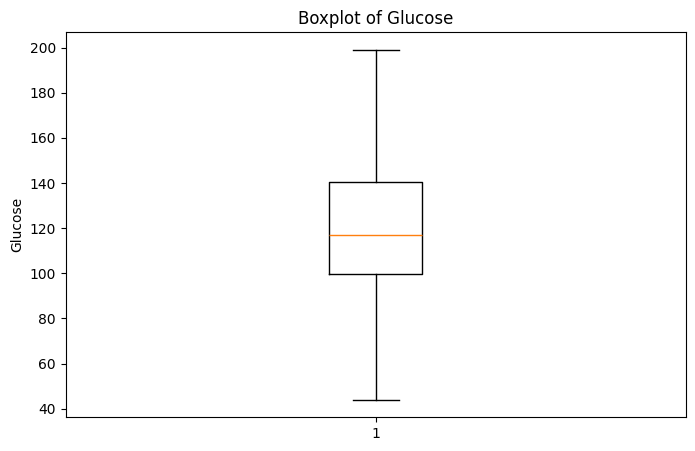

In [66]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['Glucose'])

plt.title('Boxplot of Glucose')
plt.ylabel('Glucose')

plt.show()

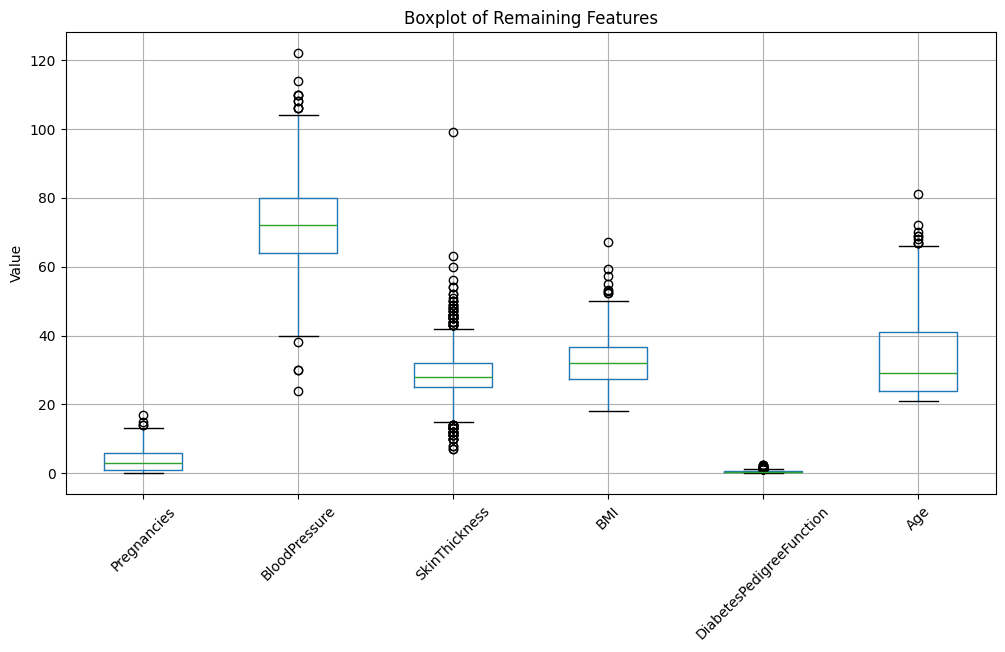

In [67]:
import matplotlib.pyplot as plt

features = [
    'Pregnancies',
    'BloodPressure',
    'SkinThickness',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

plt.figure(figsize=(12, 6))

df[features].boxplot()

plt.title('Boxplot of Remaining Features')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.show()

In [68]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((df < lower_bound) | (df > upper_bound)).sum()

print(outliers)

Pregnancies                  4
Glucose                      0
BloodPressure               14
SkinThickness               87
Insulin                     51
BMI                          8
DiabetesPedigreeFunction    29
Age                          9
Outcome                      0
dtype: int64


In [69]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print((df[zero_cols] == 0).sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [70]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (614, 8)
X_test_scaled shape: (154, 8)


In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [74]:
y_pred = model.predict(X_test_scaled)

print("Predictions:", y_pred[:10])

Predictions: [0 0 0 0 0 0 1 1 0 1]


In [75]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.7077922077922078
Model Accuracy (%): 70.77922077922078


Confusion Matrix:
[[79 21]
 [24 30]]


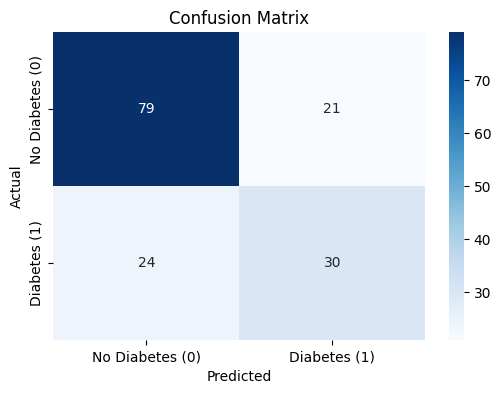

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
    yticklabels=['No Diabetes (0)', 'Diabetes (1)']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



In [78]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8262962962962963


In [79]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest training and prediction completed!")

Random Forest training and prediction completed!


In [80]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest Accuracy (%):", accuracy_rf * 100)

Random Forest Accuracy: 0.8636363636363636
Random Forest Accuracy (%): 86.36363636363636


Random Forest Confusion Matrix:
[[90 10]
 [11 43]]


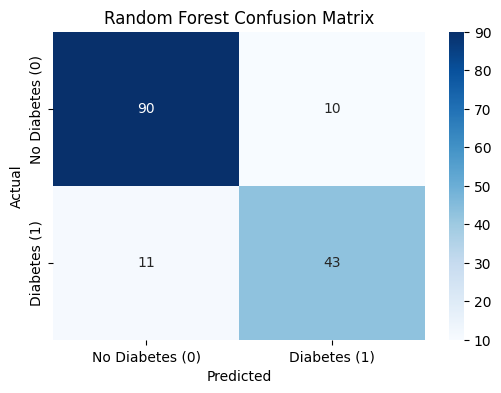

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
    yticklabels=['No Diabetes (0)', 'Diabetes (1)']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [82]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90       100
           1       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



In [83]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", auc_rf)

Random Forest ROC-AUC: 0.9436111111111111


In [84]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                    Feature  Importance
4                   Insulin    0.358367
1                   Glucose    0.173985
3             SkinThickness    0.138629
5                       BMI    0.090195
7                       Age    0.072941
6  DiabetesPedigreeFunction    0.071559
2             BloodPressure    0.048064
0               Pregnancies    0.046260


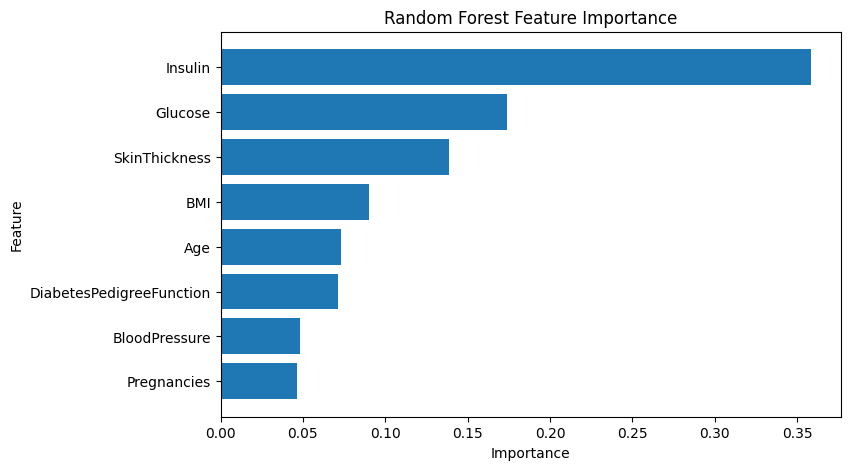

In [85]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()
plt.show()

In [86]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [0.7078, 0.8636],
    'ROC-AUC': [0.8263, 0.9436]
})

model_comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.7078,0.8263
1,Random Forest,0.8636,0.9436


In [87]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:", rf_cv_scores)
print("Mean CV Accuracy:", rf_cv_scores.mean())

Cross-validation scores: [0.86178862 0.8699187  0.88617886 0.89430894 0.86885246]
Mean CV Accuracy: 0.8762095161935226


In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy:
0.8843262694922032


In [89]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy:
0.8843262694922032


In [91]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

best_rf = grid_search.best_estimator_

# Prediction
y_pred = best_rf.predict(X_test)

# Probability for ROC-AUC
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Final Tuned Random Forest Results")
print("----------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Final Tuned Random Forest Results
----------------------------------
Accuracy : 0.35064935064935066
Precision: 0.35064935064935066
Recall   : 1.0
F1 Score : 0.5192307692307693
ROC-AUC  : 0.5192592592592592


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Confusion Matrix:
[[  0 100]
 [  0  54]]


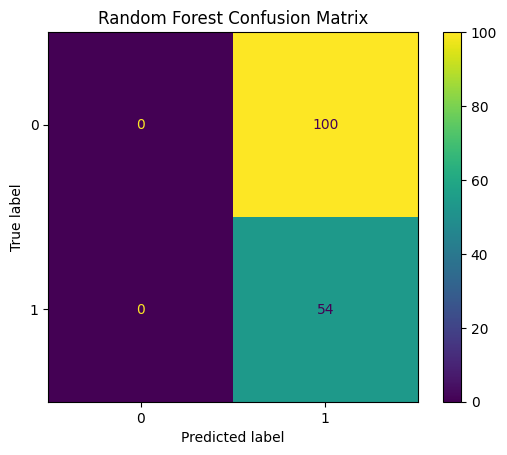

In [92]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [94]:
X_test_scaled = scaler.transform(X_test)

y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Final Tuned Random Forest Results")
print("----------------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Final Tuned Random Forest Results
----------------------------------
Accuracy : 0.8636363636363636
Precision: 0.8113207547169812
Recall   : 0.7962962962962963
F1 Score : 0.8037383177570093
ROC-AUC  : 0.9437037037037037


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Confusion Matrix:
[[  0 100]
 [  0  54]]


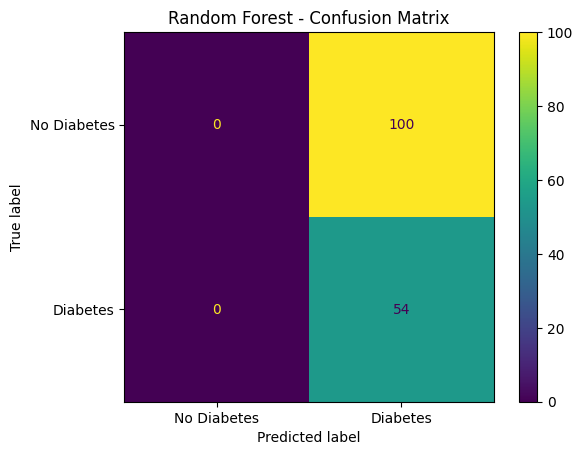

In [97]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = best_rf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [98]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\ny_test distribution:")
print(y_test.value_counts())

print("\ny_pred distribution:")
print(pd.Series(y_pred).value_counts())

print("\nFirst 20 predictions:")
print(y_pred[:20])

X_train shape: (614, 8)
X_test shape : (154, 8)

y_test distribution:
Outcome
0    100
1     54
Name: count, dtype: int64

y_pred distribution:
1    154
Name: count, dtype: int64

First 20 predictions:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [99]:
print("Model classes:")
print(best_rf.classes_)

print("\nModel parameters:")
print(best_rf.get_params())

Model classes:
[0 1]

Model parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [100]:
print("X_train type:", type(X_train))
print("X_test type :", type(X_test))

print("\nX_train columns:")
print(X_train.columns if hasattr(X_train, "columns") else "NO COLUMNS")

print("\nX_test columns:")
print(X_test.columns if hasattr(X_test, "columns") else "NO COLUMNS")

X_train type: <class 'pandas.core.frame.DataFrame'>
X_test type : <class 'pandas.core.frame.DataFrame'>

X_train columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

X_test columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')


In [101]:
print("Training accuracy:")
print(best_rf.score(X_train, y_train))

print("\nTesting accuracy:")
print(best_rf.score(X_test, y_test))

print("\nTraining predictions:")
train_pred = best_rf.predict(X_train)
print(pd.Series(train_pred).value_counts())

print("\nTesting predictions:")
test_pred = best_rf.predict(X_test)
print(pd.Series(test_pred).value_counts())

Training accuracy:
0.3485342019543974

Testing accuracy:
0.35064935064935066

Training predictions:
1    614
Name: count, dtype: int64

Testing predictions:


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


1    154
Name: count, dtype: int64


In [102]:
print("First 10 X_train:")
print(X_train.head(10))

print("\nFirst 10 y_train:")
print(y_train.head(10))

print("\nFirst 10 X_test:")
print(X_test.head(10))

print("\nFirst 10 y_test:")
print(y_test.head(10))

First 10 X_train:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
353            1       90           62.0             12     43.0  27.2   
711            5      126           78.0             27     22.0  29.6   
373            2      105           58.0             40     94.0  34.9   
46             1      146           56.0             27    102.5  29.7   
682            0       95           64.0             39    105.0  44.6   
360            5      189           64.0             33    325.0  31.2   
414            0      138           60.0             35    167.0  34.6   
339            7      178           84.0             32    169.5  39.9   
694            2       90           60.0             27    102.5  23.5   
33             6       92           92.0             27    102.5  19.9   

     DiabetesPedigreeFunction  Age  
353                     0.580   24  
711                     0.439   40  
373                     0.225   25  
46                 

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================================
# FINAL TUNED RANDOM FOREST
# ============================================

final_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Train using DataFrame directly
final_rf.fit(X_train, y_train)

# Predictions
y_pred = final_rf.predict(X_test)

# Probabilities for ROC-AUC
y_prob = final_rf.predict_proba(X_test)[:, 1]

# ============================================
# EVALUATION
# ============================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Final Tuned Random Forest Results")
print("----------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# ============================================
# CONFUSION MATRIX
# ============================================

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Diabetes", "Diabetes"]
    )
)

# ============================================
# PREDICTION DISTRIBUTION
# ============================================

print("\nPrediction Distribution:")
print(pd.Series(y_pred).value_counts())

Final Tuned Random Forest Results
----------------------------------
Accuracy : 0.8636
Precision: 0.8113
Recall   : 0.7963
F1 Score : 0.8037
ROC-AUC  : 0.9439

Confusion Matrix:
[[90 10]
 [11 43]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.89      0.90      0.90       100
    Diabetes       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154


Prediction Distribution:
0    101
1     53
Name: count, dtype: int64


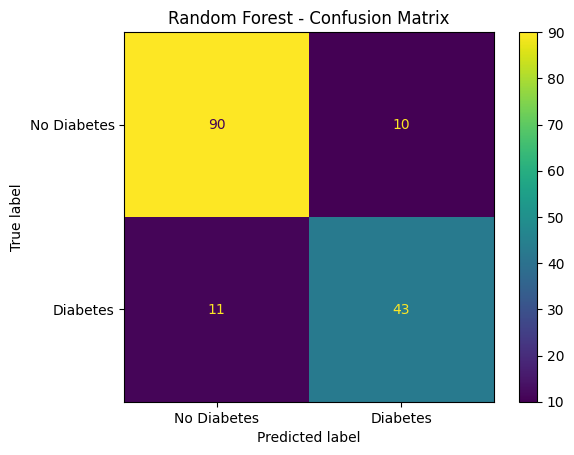

In [104]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Diabetes", "Diabetes"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

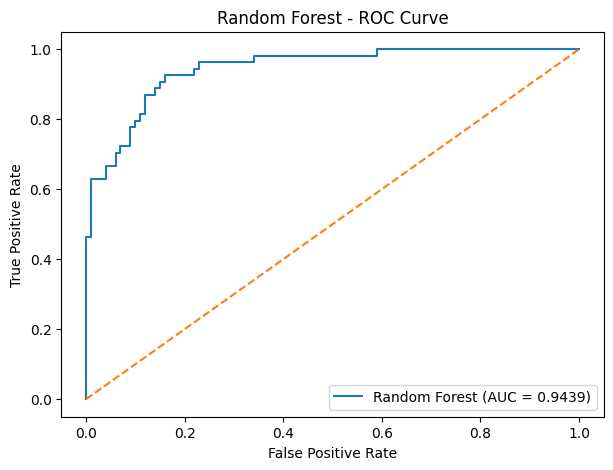

In [105]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend()
plt.show()

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    final_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

Feature Importance:
Insulin                     0.406243
Glucose                     0.196842
SkinThickness               0.155641
Age                         0.069817
BMI                         0.066832
DiabetesPedigreeFunction    0.039175
Pregnancies                 0.036990
BloodPressure               0.028460
dtype: float64


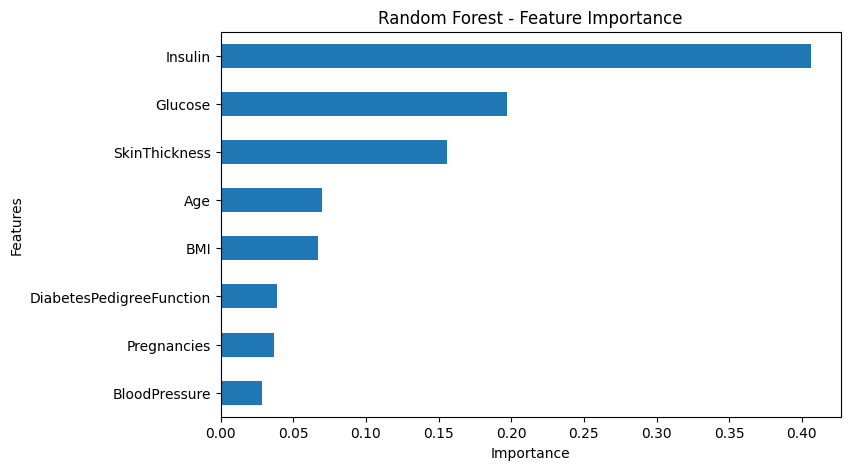

In [107]:
plt.figure(figsize=(8, 5))

importance.sort_values().plot(kind="barh")

plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

In [108]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    final_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("5-Fold Cross-Validation Results")
print("--------------------------------")
print("Fold Scores:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")

5-Fold Cross-Validation Results
--------------------------------
Fold Scores: [0.84552846 0.88617886 0.87804878 0.88617886 0.87704918]
Mean Accuracy: 0.8746
Std Deviation: 0.0150


In [109]:
!pip install shap -q


In [110]:
import shap

explainer = shap.TreeExplainer(final_rf)

shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")
print(type(shap_values))

SHAP values calculated successfully!
<class 'numpy.ndarray'>


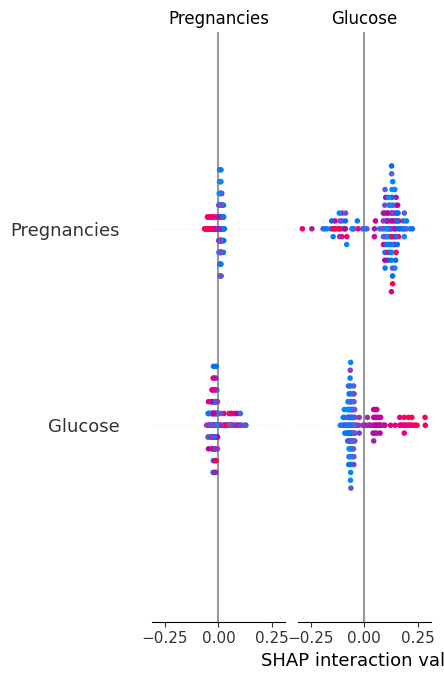

In [111]:
import shap
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)

In [112]:
import numpy as np
import shap
import matplotlib.pyplot as plt

print("SHAP shape:", shap_values.shape)

SHAP shape: (154, 8, 2)


In [113]:
# Select SHAP values for Diabetes class (class = 1)
shap_values_diabetes = shap_values[:, :, 1]

print("Selected SHAP shape:", shap_values_diabetes.shape)

Selected SHAP shape: (154, 8)


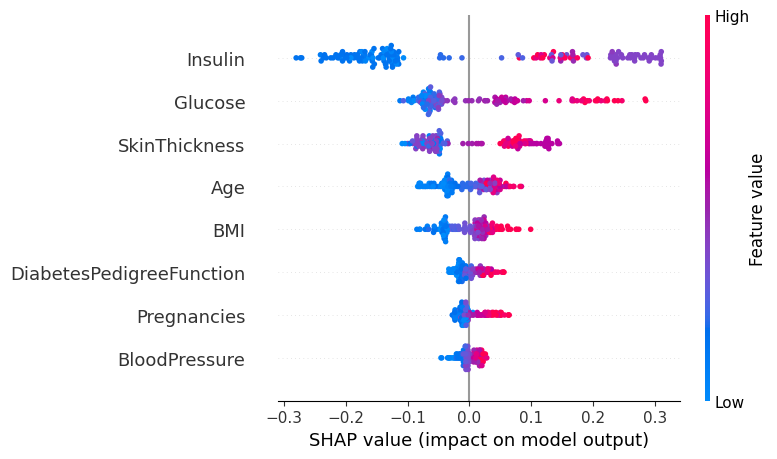

In [114]:
shap.summary_plot(
    shap_values_diabetes,
    X_test,
    feature_names=X_test.columns
)

In [115]:
import joblib

# Save final trained model
joblib.dump(final_rf, "diabetes_random_forest.pkl")

print("Final Random Forest model saved successfully!")

Final Random Forest model saved successfully!


In [116]:
import os

print("File exists:", os.path.exists("diabetes_random_forest.pkl"))

File exists: True


In [117]:
import joblib
import pandas as pd

# Load saved model
model = joblib.load("diabetes_random_forest.pkl")


def predict_diabetes(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):
    # Create input DataFrame
    input_data = pd.DataFrame([{
        "Pregnancies": pregnancies,
        "Glucose": glucose,
        "BloodPressure": blood_pressure,
        "SkinThickness": skin_thickness,
        "Insulin": insulin,
        "BMI": bmi,
        "DiabetesPedigreeFunction": diabetes_pedigree,
        "Age": age
    }])

    # Prediction
    prediction = model.predict(input_data)[0]

    # Probability
    probability = model.predict_proba(input_data)[0][1]

    if prediction == 1:
        result = "Diabetes"
    else:
        result = "No Diabetes"

    return result, probability

In [118]:
result, probability = predict_diabetes(
    pregnancies=2,
    glucose=150,
    blood_pressure=70,
    skin_thickness=30,
    insulin=100,
    bmi=33.6,
    diabetes_pedigree=0.6,
    age=35
)

print("Prediction:", result)
print(f"Diabetes Probability: {probability:.2%}")

Prediction: No Diabetes
Diabetes Probability: 25.26%


In [119]:
!mkdir -p ml_model
!cp diabetes.csv ml_model/
!cp diabetes_random_forest.pkl ml_model/

In [120]:
%%writefile ml_model/requirements.txt
pandas
numpy
scikit-learn
matplotlib
seaborn
shap
joblib

Writing ml_model/requirements.txt
